Identification of medicinal plant by DL model.

In [1]:
# Block 1: Install libraries and download + extract all five plant image zips from GitHub
!pip install tensorflow scikit-learn matplotlib -q

import os, shutil, random, requests, zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

plants = ["Aloevera", "Amla", "Amruta", "Arali", "Ashoka"]
base_url = "https://github.com/drpharmacy/pharma-ml-projects/raw/refs/heads/main/Images%20of%20Med%20Plants/"

os.makedirs("medicinal_plants", exist_ok=True)
for plant in plants:
    r = requests.get(base_url + plant + ".zip")
    with open(plant + ".zip", "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile(plant + ".zip", "r") as z:
        z.extractall("medicinal_plants")
    print(plant, "extracted")

for p in plants:
    print(p, ":", len(os.listdir(f"medicinal_plants/{p}")), "images")

Aloevera extracted
Amla extracted
Amruta extracted
Arali extracted
Ashoka extracted
Aloevera : 164 images
Amla : 146 images
Amruta : 146 images
Arali : 146 images
Ashoka : 146 images


Meaning of Block 1: Downloads all five zip files straight from GitHub and extracts each into a shared medicinal_plants/ folder, producing five class subfolders (Aloevera/, Amla/, Amruta/, Arali/, Ashoka/) — this folder structure is exactly what Keras expects: the folder name becomes the class label automatically, no manual labelling needed.

{'Aloevera': 164, 'Amla': 146, 'Amruta': 146, 'Arali': 146, 'Ashoka': 146}


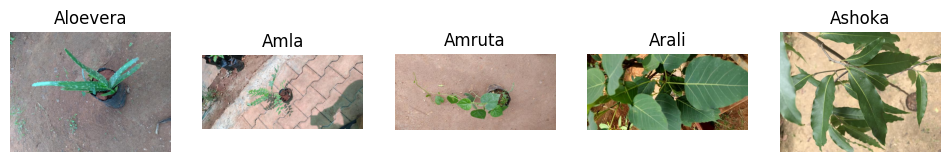

In [2]:
# Block 2: Explore the dataset — count images per class and view sample images
class_names = sorted(os.listdir("medicinal_plants"))
counts = {c: len(os.listdir(f"medicinal_plants/{c}")) for c in class_names}
print(counts)

plt.figure(figsize=(12, 6))
for i, c in enumerate(class_names):
    sample_file = os.listdir(f"medicinal_plants/{c}")[0]
    img = tf.keras.utils.load_img(f"medicinal_plants/{c}/{sample_file}")
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(c)
    plt.axis("off")
plt.show()

Meaning of Block 2: Confirms roughly balanced classes (146–164 images each — no class is starved of data) and visually verifies the images actually look like the labelled plant before any training begins — a quick sanity check that catches misplaced or corrupted files early.

In [3]:
# Block 3: Split each class into train (70%), validation (15%), and test (15%) folders
random.seed(42)
splits = {"train": 0.7, "val": 0.15, "test": 0.15}

for split in splits:
    for c in class_names:
        os.makedirs(f"split_data/{split}/{c}", exist_ok=True)

for c in class_names:
    files = os.listdir(f"medicinal_plants/{c}")
    random.shuffle(files)
    n = len(files)
    n_train, n_val = int(n * 0.7), int(n * 0.15)
    for f in files[:n_train]:
        shutil.copy(f"medicinal_plants/{c}/{f}", f"split_data/train/{c}/{f}")
    for f in files[n_train:n_train+n_val]:
        shutil.copy(f"medicinal_plants/{c}/{f}", f"split_data/val/{c}/{f}")
    for f in files[n_train+n_val:]:
        shutil.copy(f"medicinal_plants/{c}/{f}", f"split_data/test/{c}/{f}")

print("Split complete.")

Split complete.


Meaning of Block 3: Unlike the earlier tabular models (one train_test_split line), image classification needs three sets: train (learns from), validation (tunes/monitors during training), and test (final, untouched judge of real performance). Splitting is done per-class so all five plants stay proportionally represented in every split — random.seed(42) keeps the split identical every time this is run.

In [4]:
# Block 4: Load images into TensorFlow datasets and apply data augmentation
IMG_SIZE = (160, 160)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory("split_data/train", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')
val_ds   = tf.keras.utils.image_dataset_from_directory("split_data/val", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')
test_ds  = tf.keras.utils.image_dataset_from_directory("split_data/test", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical', shuffle=False)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
])

Found 522 files belonging to 5 classes.
Found 108 files belonging to 5 classes.
Found 118 files belonging to 5 classes.
Classes: ['Aloevera', 'Amla', 'Amruta', 'Arali', 'Ashoka']


Meaning of Block 4: Every image is resized to a uniform 160×160 pixels (required — the model needs a fixed input size) and grouped into batches of 16 for efficient training. data_augmentation randomly flips, rotates, and zooms training images on the fly — since only ~100–115 images per class exist for training, augmentation artificially creates variety, helping the model generalize rather than memorize the exact 500-odd training photos.

In [7]:
# Block 5: Build the CNN using transfer learning (MobileNetV2 pretrained on ImageNet)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False   # freeze the pretrained layers

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Meaning of Block 5: With only ~500 training images total, training a CNN entirely from scratch would badly overfit. Instead, MobileNetV2 — already trained on 1.4 million general images — is used as a fixed feature extractor (base_model.trainable = False freezes its learned weights), and only a small new classification head (the last few layers) is trained on top for our five plants. This is transfer learning, the same core technique used for the LSTM in the de novo design notebook, applied here to images instead of molecules — it lets a small dataset still produce a strong, generalizable model.

Epoch 1/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 575ms/step - accuracy: 0.4847 - loss: 1.3251 - val_accuracy: 0.8519 - val_loss: 0.5400
Epoch 2/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 26s 782ms/step - accuracy: 0.8525 - loss: 0.4363 - val_accuracy: 0.9259 - val_loss: 0.2801
Epoch 3/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 695ms/step - accuracy: 0.9253 - loss: 0.2617 - val_accuracy: 0.9444 - val_loss: 0.1906
Epoch 4/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 34s 485ms/step - accuracy: 0.9387 - loss: 0.2110 - val_accuracy: 0.9444 - val_loss: 0.1538
Epoch 5/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 453ms/step - accuracy: 0.9483 - loss: 0.1626 - val_accuracy: 0.9537 - val_loss: 0.1090
Epoch 6/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 453ms/step - accuracy: 0.9713 - loss: 0.0963 - val_accuracy: 0.9722 - val_loss: 0.1026
Epoch 7/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 432ms/step - accuracy: 0.9751 - loss: 0.0925 - val_accuracy: 0.9630 - val_loss: 0.0941
Epoch 8/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 697ms/step - accuracy: 0.9904 - loss: 0.0705 - val_accu

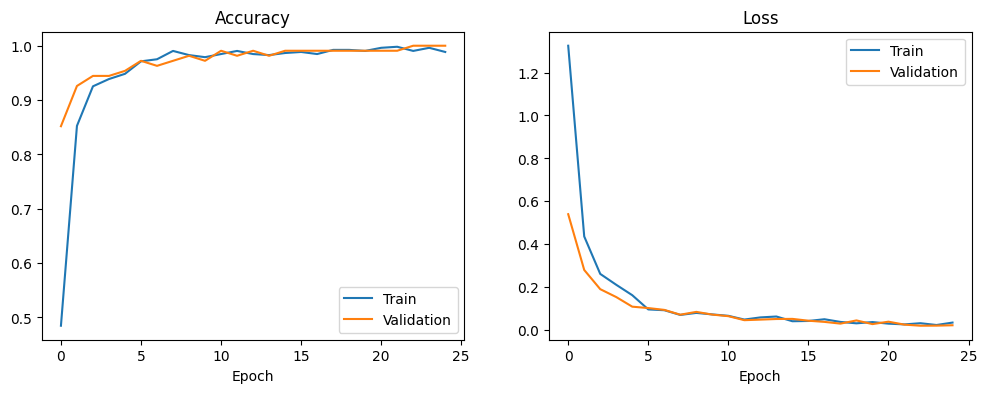

In [6]:
# Block 6: Train the model
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=[early_stop])

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend()
plt.show()

Meaning of Block 6: Trains for up to 25 epochs, but EarlyStopping automatically halts training if validation loss stops improving for 5 straight epochs (and restores the best-performing weights seen) — this prevents wasting time training past the point of overfitting. The two plots let you visually confirm healthy training: both accuracy curves should rise together, and both loss curves should fall together; a widening gap between train and validation lines would signal overfitting.

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 289ms/step - accuracy: 0.1610 - loss: 2.4782
Test Accuracy: 0.1610
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 391ms/step


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    Aloevera       0.09      0.12      0.10        26
        Amla       0.00      0.00      0.00        23
      Amruta       0.14      0.43      0.22        23
       Arali       0.00      0.00      0.00        23
      Ashoka       0.50      0.26      0.34        23

    accuracy                           0.16       118
   macro avg       0.15      0.16      0.13       118
weighted avg       0.14      0.16      0.13       118



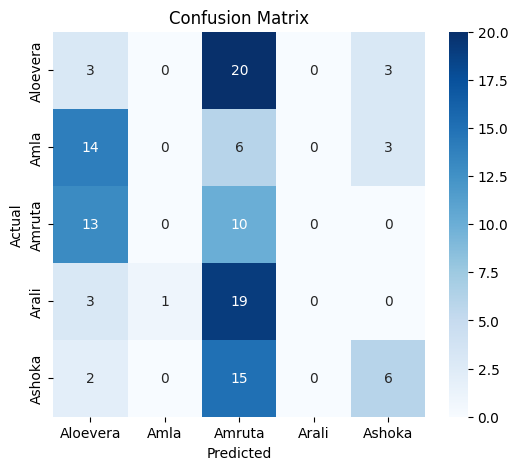

In [8]:
# Block 7: Evaluate on the held-out test set — accuracy, confusion matrix, classification report
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

y_true = np.concatenate([y.numpy() for x, y in test_ds])
y_true = np.argmax(y_true, axis=1)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

Meaning of Block 7: This is the real validation — evaluated only on the 118 test images the model has never seen in training or validation. The classification report shows precision/recall/F1 per plant, revealing if any single species is being confused more than others; the confusion matrix visualizes exactly which plants get mistaken for which — e.g. if Amruta and Arali are visually similar leaves, their row/column might show cross-confusion, useful diagnostic information a single accuracy number would hide.

In [10]:
# Block 8: Save the trained model and class labels
model.save("medicinal_plant_cnn_model.keras")

import json
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

from google.colab import files
files.download("medicinal_plant_cnn_model.keras")
files.download("class_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Meaning of Block 8: Saves the complete trained model (architecture + learned weights) as a single .keras file, and separately saves class_names.json — the exact order of class labels the model outputs predictions in. Both are required together: reloading the model without knowing the label order would let you get a prediction like class index 2 with no way to know that means "Arali."

In [ ]:
# Block 9 (FINAL STAGE): Upload unknown plant image(s) and get the model's prediction
from google.colab import files
import tensorflow as tf
import numpy as np

# If starting a fresh session without Blocks 1-8 already run, reload model + labels instead:
# model = tf.keras.models.load_model("medicinal_plant_cnn_model.keras")
# import json; class_names = json.load(open("class_names.json"))

uploaded = files.upload()   # select one or more image files (.jpg/.png) of unknown plants

for fname in uploaded.keys():
    img = tf.keras.utils.load_img(fname, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)   # add batch dimension

    predictions = model.predict(img_array, verbose=0)[0]
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    plt.figure()
    plt.imshow(img)
    plt.title(f"{fname}\nPredicted: {predicted_class} ({confidence:.1f}% confidence)")
    plt.axis("off")
    plt.show()

    print(f"\n{fname}")
    for cname, prob in zip(class_names, predictions):
        print(f"  {cname}: {prob*100:.2f}%")

Meaning of Block 9: This is the deployment step — the whole point of building the model. files.upload() opens a file picker so you (or a student) can upload any photo of a plant leaf, including species outside the training photos entirely, or the same species photographed in a new setting. For each uploaded image: it's resized to match training dimensions, passed through the trained model, and the class with the highest predicted probability is shown as the prediction, displayed directly on the image with its confidence percentage — plus the full probability breakdown across all five classes underneath, so you can see how confident (or uncertain) the model actually was, not just its final guess.

Important: This model can only ever predict one of the five plants it was trained on — if an unrelated plant (or a non-plant image) is uploaded, it will still confidently output one of the five labels, since a softmax classifier always picks its "best guess" among known classes rather than saying "none of these." A very low confidence score (e.g. under ~50–60%) across all five classes is the practical signal that the uploaded image likely isn't one of the trained species.